In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import os

# Ensure visualization directory exists
os.makedirs('visualizations', exist_ok=True)

In [15]:
# Load local dataset
df_snapshot = pd.read_csv("data/cleaned_fitness_data.csv")
expanded_rows = []
dates = pd.date_range(end=pd.Timestamp.now(), periods=30, freq='D')

for _, row in df_snapshot.head(5).iterrows():
    uid = row['Id']
    base_hr = row['heart_rate']
    base_steps = row['step_count']
    # Handle non-numeric sleep if present, default to 480 (8 hours)
    base_sleep = 480 

    for date in dates:
        # Create daily variations with noise
        daily_hr = np.random.normal(base_hr, 5)
        daily_steps = max(0, np.random.normal(10000 if np.isnan(base_steps) else base_steps, 2000))
        daily_sleep = np.random.normal(base_sleep, 60)

        # Inject Occasional Anomalies
        if np.random.random() < 0.05: daily_hr += 40  # Heart rate spike
        if np.random.random() < 0.05: daily_sleep -= 300 # Sleep deprivation

        expanded_rows.append({
            "Id": uid,
            "Date": date,
            "TotalSteps": daily_steps,
            "AvgHeartRate": daily_hr,
            "TotalSleepMinutes": daily_sleep
        })

df = pd.DataFrame(expanded_rows)
df["timestamp"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)

user_ids = df["Id"].unique()
df.head()

,Id,Date,TotalSteps,AvgHeartRate,TotalSleepMinutes,timestamp
0,P0001,2025-12-15 13:39:34.027654,1119.491487,70.473112,536.089728,2025-12-15 13:39:34.027654
1,P0001,2025-12-16 13:39:34.027654,0.000000,76.165144,436.812998,2025-12-16 13:39:34.027654
2,P0001,2025-12-17 13:39:34.027654,506.605209,73.417475,432.370378,2025-12-17 13:39:34.027654
3,P0001,2025-12-18 13:39:34.027654,1888.451840,73.139402,431.622633,2025-12-18 13:39:34.027654
4,P0001,2025-12-19 13:39:34.027654,524.366266,67.462739,447.342317,2025-12-19 13:39:34.027654


In [16]:
all_anomalies_hr = []

for uid in user_ids:
    user_df = df[df["Id"] == uid]

    hr = user_df[["timestamp", "AvgHeartRate"]].dropna()
    hr = hr.rename(columns={"timestamp": "ds", "AvgHeartRate": "y"})
    if len(hr) < 2:
        continue
        
    
    hr = hr.sort_values("ds")

    model = Prophet(daily_seasonality=True)
    model.fit(hr)

    future = model.make_future_dataframe(periods=7)
    forecast = model.predict(future)

    merged = hr.merge(forecast[["ds", "yhat"]], on="ds", how="left")
    merged["residual"] = merged["y"] - merged["yhat"]

    merged["user_id"] = uid
    all_anomalies_hr.append(merged)

hr_results = pd.concat(all_anomalies_hr, ignore_index=True)
hr_results.head()

13:39:34 - cmdstanpy - INFO - Chain [1] start processing
13:39:34 - cmdstanpy - INFO - Chain [1] done processing
13:39:34 - cmdstanpy - INFO - Chain [1] start processing
13:39:34 - cmdstanpy - INFO - Chain [1] done processing
13:39:35 - cmdstanpy - INFO - Chain [1] start processing
13:39:35 - cmdstanpy - INFO - Chain [1] done processing
13:39:35 - cmdstanpy - INFO - Chain [1] start processing
13:39:35 - cmdstanpy - INFO - Chain [1] done processing
13:39:35 - cmdstanpy - INFO - Chain [1] start processing
13:39:36 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,yhat,residual,user_id
0,2025-12-15 13:39:34.027654,70.473112,74.211710,-3.738598,P0001
1,2025-12-16 13:39:34.027654,76.165144,77.551177,-1.386034,P0001
2,2025-12-17 13:39:34.027654,73.417475,73.872015,-0.454540,P0001
3,2025-12-18 13:39:34.027654,73.139402,76.245874,-3.106472,P0001
4,2025-12-19 13:39:34.027654,67.462739,78.152708,-10.689969,P0001


In [17]:
#Threshold-based Anomaly Detection
threshold_hr = 2 * hr_results["residual"].std()

hr_results["anomaly"] = abs(hr_results["residual"]) > threshold_hr
hr_results["label"] = hr_results["anomaly"].map(
    {True: "Anomalous", False: "Normal"}
)

hr_results[hr_results["anomaly"]].head()

,ds,y,yhat,residual,user_id,anomaly,label
12,2025-12-27 13:39:34.027654,118.325196,89.797870,28.527326,P0001,True,Anomalous
31,2025-12-16 13:39:34.027654,129.187647,106.523378,22.664269,P0002,True,Anomalous
37,2025-12-22 13:39:34.027654,127.087025,103.118739,23.968286,P0002,True,Anomalous
72,2025-12-27 13:39:34.027654,104.166160,68.617103,35.549057,P0003,True,Anomalous
77,2026-01-01 13:39:34.027654,101.730014,73.953550,27.776463,P0003,True,Anomalous


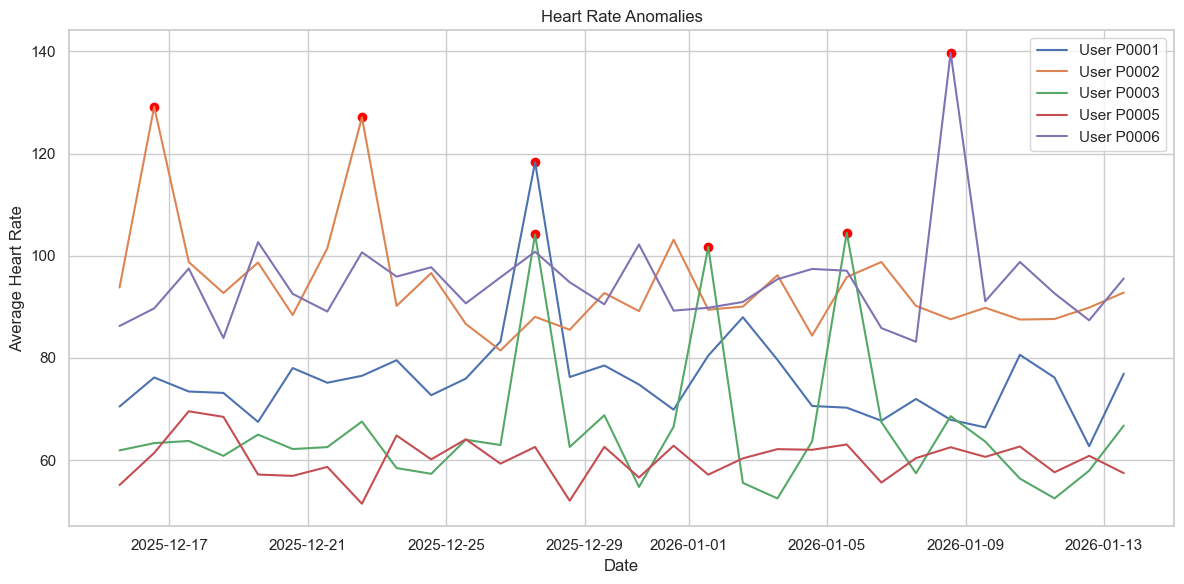

In [18]:
plt.figure(figsize=(12, 6))

for uid in user_ids:
    user_data = hr_results[hr_results["user_id"] == uid]

    # Plot heart rate trend
    plt.plot(
        user_data["ds"],
        user_data["y"],
        label=f"User {uid}"
    )

    # Select anomalous points
    anomalies = user_data[user_data["label"] == "Anomalous"]

    # Plot anomalies only if they exist
    if not anomalies.empty:
        plt.scatter(
            anomalies["ds"],
            anomalies["y"],
            color="red",
            marker="o"
        )

plt.title("Heart Rate Anomalies")
plt.xlabel("Date")
plt.ylabel("Average Heart Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    "visualizations/heart_rate_anomalies.png"
)

plt.show()

13:39:37 - cmdstanpy - INFO - Chain [1] start processing
13:39:37 - cmdstanpy - INFO - Chain [1] done processing
13:39:38 - cmdstanpy - INFO - Chain [1] start processing
13:39:38 - cmdstanpy - INFO - Chain [1] done processing
13:39:38 - cmdstanpy - INFO - Chain [1] start processing
13:39:39 - cmdstanpy - INFO - Chain [1] done processing
13:39:39 - cmdstanpy - INFO - Chain [1] start processing
13:39:39 - cmdstanpy - INFO - Chain [1] done processing
13:39:40 - cmdstanpy - INFO - Chain [1] start processing
13:39:40 - cmdstanpy - INFO - Chain [1] done processing


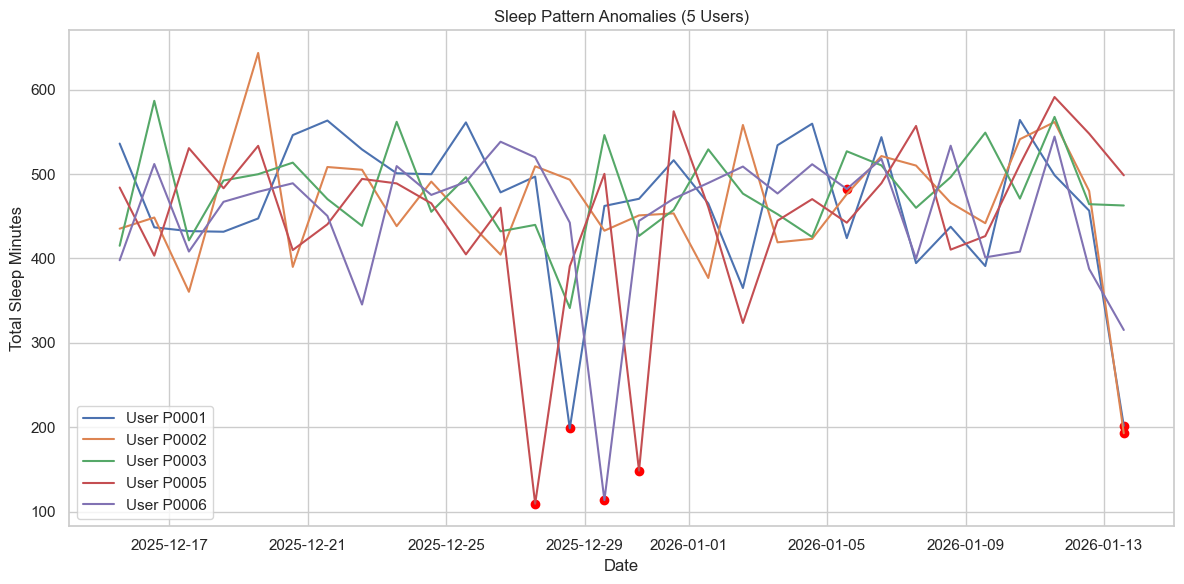

In [19]:
# Sleep Residuals & Anomalies
all_anomalies_sleep = []

for uid in user_ids:
    user_df = df[df["Id"] == uid]

    # Use correct sleep column
    sleep = user_df[["timestamp", "TotalSleepMinutes"]].dropna()
    sleep = sleep.rename(columns={"timestamp": "ds", "TotalSleepMinutes": "y"})
    # Resample if needed, but ensure data is sorted
    sleep = sleep.sort_values("ds")

    if len(sleep) < 2:
        continue

    model = Prophet(daily_seasonality=True)
    model.fit(sleep)

    future = model.make_future_dataframe(periods=7)
    forecast = model.predict(future)

    merged = sleep.merge(forecast[["ds", "yhat"]], on="ds", how="left")
    merged["residual"] = merged["y"] - merged["yhat"]
    merged["user_id"] = uid

    all_anomalies_sleep.append(merged)

sleep_results = pd.concat(all_anomalies_sleep, ignore_index=True)

# Abnormal sleep patterns visualization
threshold_sleep = 2 * sleep_results["residual"].std()
sleep_results["anomaly"] = np.abs(sleep_results["residual"]) > threshold_sleep

plt.figure(figsize=(12, 6))

for uid in user_ids:
    user_data = sleep_results[sleep_results["user_id"] == uid]

    # Plot sleep trend
    plt.plot(
        user_data["ds"],
        user_data["y"],
        label=f"User {uid}"
    )

    # Plot anomalies
    anomalies = user_data[user_data["anomaly"]]
    if not anomalies.empty:
        plt.scatter(
            anomalies["ds"],
            anomalies["y"],
            color="red",
            marker="o"
        )

plt.title("Sleep Pattern Anomalies (5 Users)")
plt.xlabel("Date")
plt.ylabel("Total Sleep Minutes")
plt.legend()
plt.tight_layout()

plt.savefig(
    "visualizations/sleep_anomalies.png"
)

plt.show()

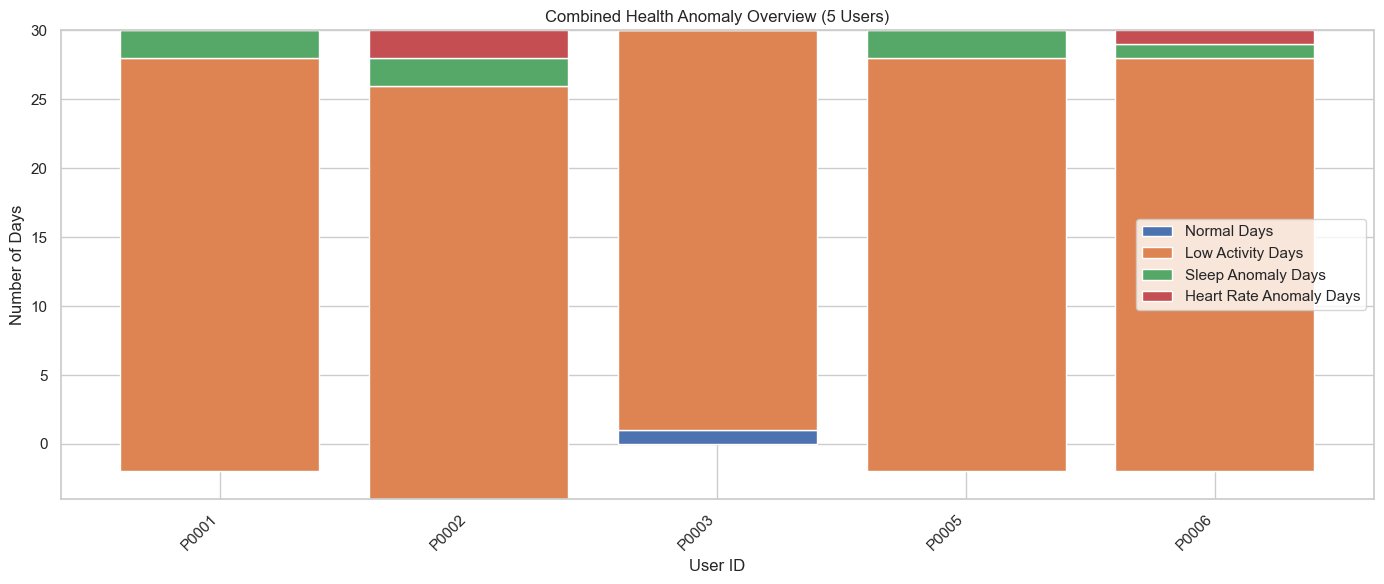

In [20]:
# Anomaly rules
df['step_anomaly'] = df['TotalSteps'] < 5000
df['sleep_anomaly'] = (df['TotalSleepMinutes'] < 300) | (df['TotalSleepMinutes'] > 600)
df['hr_anomaly'] = df['AvgHeartRate'] > 120

# Aggregate per user
summary = df.groupby('Id').agg(
    HeartRate_Anomaly_Days=('hr_anomaly', 'sum'),
    Sleep_Anomaly_Days=('sleep_anomaly', 'sum'),
    Step_Anomaly_Days=('step_anomaly', 'sum'),
    Total_Days=('Date', 'count')
).reset_index()

summary['Normal_Days'] = (
    summary['Total_Days']
    - summary['HeartRate_Anomaly_Days']
    - summary['Sleep_Anomaly_Days']
    - summary['Step_Anomaly_Days']
)

#  Take 5 users
summary = summary.head(5)

# Plot
plt.figure(figsize=(14,6))

x = summary['Id'].astype(str)

plt.bar(x, summary['Normal_Days'], label='Normal Days')
plt.bar(x, summary['Step_Anomaly_Days'],
        bottom=summary['Normal_Days'], label='Low Activity Days')
plt.bar(x, summary['Sleep_Anomaly_Days'],
        bottom=summary['Normal_Days'] + summary['Step_Anomaly_Days'],
        label='Sleep Anomaly Days')
plt.bar(x, summary['HeartRate_Anomaly_Days'],
        bottom=summary['Normal_Days'] + summary['Step_Anomaly_Days'] + summary['Sleep_Anomaly_Days'],
        label='Heart Rate Anomaly Days')

plt.xlabel("User ID")
plt.ylabel("Number of Days")
plt.title("Combined Health Anomaly Overview (5 Users)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("visualizations/combined_anomalies.png")
plt.show()